In [1]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


DIGITAL HEALTH PLATFORM GROWTH CONSULTING

Dataset Shape:
(9000, 5)

First 5 Rows:
   user_id  patient_id  session_count  avg_session_time  dropped_out
0        1        2048              1                25            0
1        2         262             23                23            0
2        3        2315             48                42            0
3        4         930             13                27            0
4        5        2660             41                42            0

Missing Values
user_id             0
patient_id          0
session_count       0
avg_session_time    0
dropped_out         0
dtype: int64

Summary Statistics
           user_id   patient_id  session_count  avg_session_time  dropped_out
count  9000.000000  9000.000000    9000.000000       9000.000000  9000.000000
mean   4500.500000  1485.087000      25.159222         30.236222     0.248111
std    2598.220545   868.390219      14.140646         17.022493     0.431941
min       1.000000     1.000000 

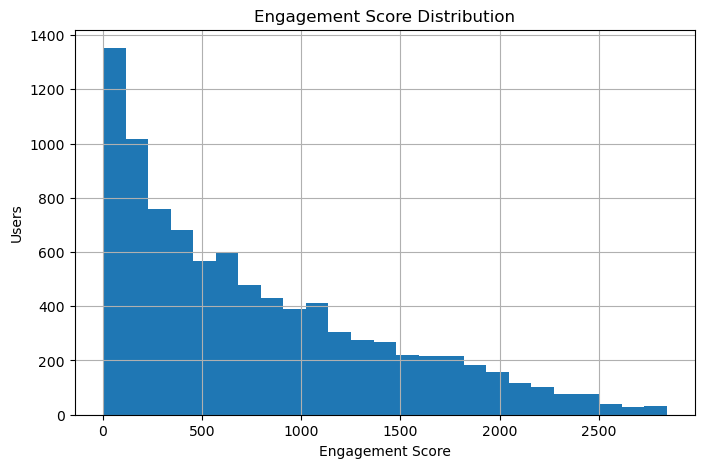


USER SEGMENTATION
engagement_segment
Low Engagement       4049
Medium Engagement    2795
High Engagement      2156
Name: count, dtype: int64

CONSULTING INSIGHT:
Segmenting users helps identify
high-value users and users at risk.



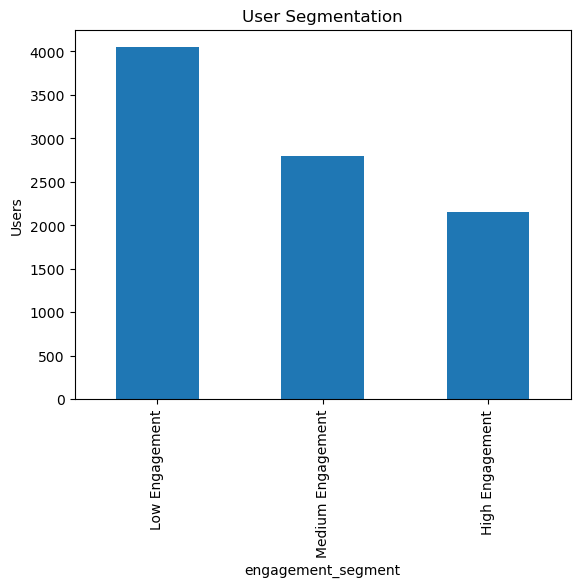


SEGMENT ANALYSIS
                    user_id  session_count  avg_session_time  dropped_out
engagement_segment                                                       
High Engagement        2156      38.269017         46.210575     0.240260
Low Engagement         4049      16.486293         19.541862     0.252655
Medium Engagement      2795      27.610733         33.406440     0.247585

CHURN BY SEGMENT
engagement_segment
High Engagement      24.025974
Low Engagement       25.265498
Medium Engagement    24.758497
Name: dropped_out, dtype: float64


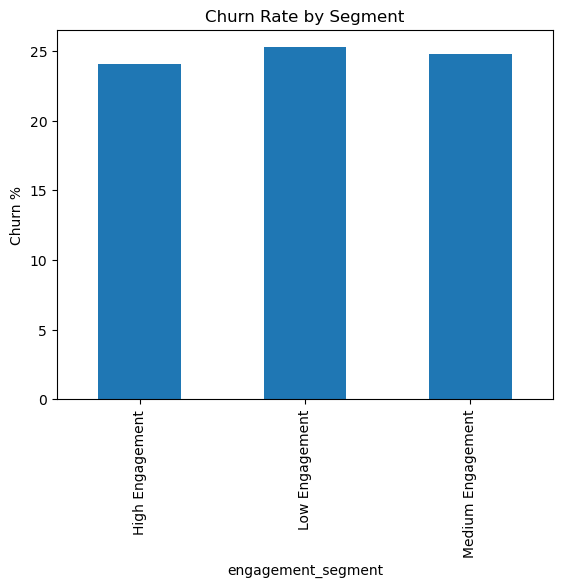


EXECUTIVE INSIGHT:
Users with lower engagement scores
are expected to demonstrate higher
churn risk and should be prioritized
for retention initiatives.


CORRELATION ANALYSIS
                  session_count  avg_session_time  engagement_score  \
session_count          1.000000          0.014031          0.659232   
avg_session_time       0.014031          1.000000          0.666106   
engagement_score       0.659232          0.666106          1.000000   
dropped_out           -0.007615          0.010119         -0.005439   

                  dropped_out  
session_count       -0.007615  
avg_session_time     0.010119  
engagement_score    -0.005439  
dropped_out          1.000000  

CHURN PREDICTION MODEL

Model Accuracy: 0.56

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.61      0.67      1343
           1       0.25      0.38      0.30       457

    accuracy                           0.56      1800
   macro avg       0

In [14]:
# ==========================================
# DIGITAL HEALTH PLATFORM GROWTH CONSULTING
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("/Users/ayushh.h/Downloads/app_usage.csv")

print("="*60)
print("DIGITAL HEALTH PLATFORM GROWTH CONSULTING")
print("="*60)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ==========================================
# DATA QUALITY CHECK
# ==========================================

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())

# ==========================================
# CHURN ANALYSIS
# ==========================================

print("\n"+"="*60)
print("CHURN ANALYSIS")
print("="*60)

print("\nChurn Distribution")

print(df["dropped_out"].value_counts())

print("\nChurn Percentage")

print(
    round(
        df["dropped_out"].value_counts(normalize=True)*100,
        2
    )
)

churn_rate = round(
    df["dropped_out"].mean()*100,
    2
)

print("\nOverall Churn Rate:",churn_rate,"%")

print(
"""
BUSINESS INSIGHT:
Churn rate represents users who stopped
using the platform. Understanding churn
is critical for retention strategy.
"""
)

# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("\n"+"="*60)
print("FEATURE ENGINEERING")
print("="*60)

df["engagement_score"] = (
    df["session_count"]
    *
    df["avg_session_time"]
)

print("\nEngagement Score Created")

print(df["engagement_score"].describe())

print(
"""
BUSINESS INSIGHT:
Engagement Score combines usage frequency
and time spent on platform.
Higher score = stronger engagement.
"""
)

# ==========================================
# VISUALIZATION 1
# ==========================================

plt.figure(figsize=(8,5))

df["engagement_score"].hist(
    bins=25
)

plt.title("Engagement Score Distribution")

plt.xlabel("Engagement Score")

plt.ylabel("Users")

plt.show()

# ==========================================
# USER SEGMENTATION
# ==========================================

print("\n"+"="*60)
print("USER SEGMENTATION")
print("="*60)

def segment(score):

    if score >= 1200:
        return "High Engagement"

    elif score >= 500:
        return "Medium Engagement"

    else:
        return "Low Engagement"

df["engagement_segment"] = df[
    "engagement_score"
].apply(segment)

print(
    df["engagement_segment"]
    .value_counts()
)

print(
"""
CONSULTING INSIGHT:
Segmenting users helps identify
high-value users and users at risk.
"""
)

# ==========================================
# VISUALIZATION 2
# ==========================================

df["engagement_segment"].value_counts().plot(
    kind="bar"
)

plt.title("User Segmentation")

plt.ylabel("Users")

plt.show()

# ==========================================
# SEGMENT ANALYSIS
# ==========================================

print("\n"+"="*60)
print("SEGMENT ANALYSIS")
print("="*60)

segment_summary = df.groupby(
    "engagement_segment"
).agg({
    "user_id":"count",
    "session_count":"mean",
    "avg_session_time":"mean",
    "dropped_out":"mean"
})

print(segment_summary)

# ==========================================
# CHURN BY SEGMENT
# ==========================================

print("\n"+"="*60)
print("CHURN BY SEGMENT")
print("="*60)

churn_segment = (
    df.groupby(
        "engagement_segment"
    )["dropped_out"]
    .mean()
    *100
)

print(churn_segment)

churn_segment.plot(
    kind="bar"
)

plt.title("Churn Rate by Segment")

plt.ylabel("Churn %")

plt.show()

print(
"""
EXECUTIVE INSIGHT:
Users with lower engagement scores
are expected to demonstrate higher
churn risk and should be prioritized
for retention initiatives.
"""
)

# ==========================================
# CORRELATION ANALYSIS
# ==========================================

print("\n"+"="*60)
print("CORRELATION ANALYSIS")
print("="*60)

print(
    df[
        [
            "session_count",
            "avg_session_time",
            "engagement_score",
            "dropped_out"
        ]
    ].corr()
)

# ==========================================
# CHURN PREDICTION MODEL
# ==========================================

print("\n"+"="*60)
print("CHURN PREDICTION MODEL")
print("="*60)

X = df[
[
    "session_count",
    "avg_session_time",
    "engagement_score"
]
]

y = df["dropped_out"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

pred = model.predict(X_test)

print(
    "\nModel Accuracy:",
    round(
        accuracy_score(
            y_test,
            pred
        ),
        2
    )
)

print("\nClassification Report")

print(
    classification_report(
        y_test,
        pred
    )
)

print("\nConfusion Matrix")

print(
    confusion_matrix(
        y_test,
        pred
    )
)

print(
"""
MODEL INTERPRETATION:
The model serves as an early warning
system for identifying potentially
at-risk users based on engagement
behavior patterns.
"""
)

# ==========================================
# CONSULTING RECOMMENDATIONS
# ==========================================

print("\n"+"="*60)
print("CONSULTING RECOMMENDATIONS")
print("="*60)

recommendations = [
    "Improve onboarding experience",
    "Launch personalized reminder campaigns",
    "Introduce rewards for repeat platform usage",
    "Monitor engagement score as a KPI",
    "Target low-engagement users with retention interventions"
]

for i,r in enumerate(recommendations,1):
    print(f"{i}. {r}")

# ==========================================
# EXECUTIVE SUMMARY
# ==========================================

print("\n"+"="*60)
print("EXECUTIVE SUMMARY")
print("="*60)

print("Total Users:",len(df))

print(
    "Average Sessions:",
    round(
        df["session_count"].mean(),
        2
    )
)

print(
    "Average Session Time:",
    round(
        df["avg_session_time"].mean(),
        2
    )
)

print(
    "Churn Rate:",
    round(
        df["dropped_out"].mean()*100,
        2
    ),
    "%"
)

print(
"""
PROJECT CONCLUSION

This consulting engagement analyzed
digital health user behavior to identify
engagement drivers and churn patterns.

Key outcome:
Engagement score emerged as a practical
indicator for segmenting users and
supporting retention-focused business
strategies.
"""
)